In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import joblib

print("Imports done")

Imports done


In [8]:
import joblib

CLASSIFIER_PATH = "/content/drive/MyDrive/Chronos_ML/best_classifier.pkl"
REGRESSOR_PATH = "/content/drive/MyDrive/Chronos_ML/best_regressor.pkl"
FEATURES_PATH = "/content/drive/MyDrive/Chronos_ML/all_feature_names.pkl"

try:
    classifier_pipeline = joblib.load(CLASSIFIER_PATH)
    print("Loaded: classifier pipeline")

    regressor_pipeline = joblib.load(REGRESSOR_PATH)
    print("Loaded: regressor pipeline")

    feature_names = joblib.load(FEATURES_PATH)
    print("Loaded: feature names")

    print("Pipeline artifacts loaded successfully.")

except Exception as e:
    print(f"Error loading files: {e}")

Loaded: classifier pipeline
Loaded: regressor pipeline
Loaded: feature names
Pipeline artifacts loaded successfully.


In [10]:
import pandas as pd

# The pipelines and feature names have already been loaded in a previous cell (VPMw1a2okJAh).
# We will use those variables directly instead of attempting to load new files.
# This resolves the FileNotFoundError.

# Use the classifier_pipeline loaded in cell VPMw1a2okJAh
clf_pipeline  = classifier_pipeline

# Use the regressor_pipeline loaded in cell VPMw1a2okJAh
reg_pipeline  = regressor_pipeline

# Use the feature_names loaded in cell VPMw1a2okJAh for feature_cols.
# If 'feature_importance_results (1).csv' is specifically required, ensure it's in the correct path and load it.
# Otherwise, using the already loaded 'feature_names' is the logical step to proceed.
feature_cols = feature_names

print("Pipelines and feature names are available from previous steps.")
print(f"Total features expected: {len(feature_cols)}")
print()
print("Feature list:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {f}")

Pipelines and feature names are available from previous steps.
Total features expected: 45

Feature list:
   1. learning_rate
   2. n_estimators
   3. max_depth
   4. batch_size
   5. epochs
   6. num_leaves
   7. subsample
   8. dropout
   9. weight_decay
  10. warmup_steps
  11. n_clusters
  12. gamma
  13. clip_range
  14. reg_lambda
  15. colsample_bytree
  16. total_hyperparams
  17. hp_completeness
  18. log_total_train_rows
  19. log_n_estimators
  20. max_features
  21. avg_features
  22. dataset_count
  23. dataset_complexity_score
  24. data_richness
  25. feature_density
  26. duration_hours
  27. artifact_size_gb
  28. total_snapshots
  29. user_total_runs
  30. user_success_rate_pct
  31. is_deep_learning
  32. is_ensemble
  33. is_business_hours
  34. is_weekend
  35. lr_x_epochs
  36. is_public
  37. start_hour
  38. start_month
  39. deployment_count
  40. category
  41. problem_type
  42. algorithm
  43. user_role
  44. license_type
  45. version_status


In [11]:
new_run = {

    # ── Hyperparameters ──────────────────────────────────────
    # Fill in the ones relevant to your algorithm
    # Leave others as None
    'learning_rate'          : 0.05,
    'n_estimators'           : 300,
    'max_depth'              : 6,
    'batch_size'             : 64,
    'epochs'                 : 20,
    'num_leaves'             : None,
    'subsample'              : 0.8,
    'dropout'                : None,
    'weight_decay'           : None,
    'warmup_steps'           : None,
    'n_clusters'             : None,
    'gamma'                  : None,
    'clip_range'             : None,
    'reg_lambda'             : 1.0,
    'colsample_bytree'       : 0.7,
    'total_hyperparams'      : 6,

    # ── Dataset info ─────────────────────────────────────────
    # total_train_rows : actual number of rows in training set
    # max_features     : number of feature columns in dataset
    # dataset_count    : how many datasets joined for training
    'log_total_train_rows'   : np.log1p(250000),
    'max_features'           : 45,
    'avg_features'           : 40.0,
    'dataset_count'          : 2,
    'dataset_complexity_score': round(np.log1p(250000) * 45, 4),
    'largest_dataset_rows'   : np.log1p(200000),
    'smallest_dataset_rows'  : np.log1p(50000),

    # ── Engineered features ──────────────────────────────────
    # These are computed from the values above
    # Formula shown as comment — just update if you change inputs
    'hp_completeness'        : 5/7,                          # filled HPs / total HPs
    'lr_x_epochs'            : 0.05 * 20,                   # learning_rate × epochs
    'data_richness'          : np.log1p(250000) * np.log1p(45),  # log(rows) × log(features)
    'feature_density'        : 45 / (2 + 1),                # max_features / (dataset_count + 1)

    # ── Algorithm flags ──────────────────────────────────────
    # Set 1 if true, 0 if false
    'is_deep_learning'       : 0,   # 1 for BERT, ResNet, LSTM, YOLo etc.
    'is_ensemble'            : 1,   # 1 for XGBoost, Random Forest, LightGBM etc.

    # ── Time context ─────────────────────────────────────────
    'is_business_hours'      : 1,   # 1 if run starts between 9am-6pm
    'is_weekend'             : 0,   # 1 if run starts on Saturday or Sunday
    'start_hour'             : 10,  # 0-23
    'start_month'            : 6,   # 1-12

    # ── Run context ──────────────────────────────────────────
    'duration_hours'         : None,  # leave None — run hasn't finished yet
    'total_snapshots'        : None,  # leave None — unknown before completion
    'artifact_size_gb'       : None,  # leave None — unknown before completion
    'deployment_count'       : 0,     # previous deployments of this model version

    # ── User context ─────────────────────────────────────────
    'user_total_runs'        : 12,
    'user_success_rate_pct'  : 83.3,

    # ── Model metadata ───────────────────────────────────────
    'is_public'              : 0,

    # ── Categorical fields ───────────────────────────────────
    # Must be lowercase, exactly as they appear in training data
    'category'               : 'supervised learning',
    'problem_type'           : 'classification',
    'algorithm'              : 'xgboost',
    'user_role'              : 'data scientist',
    'license_type'           : 'mit',
    'version_status'         : 'staging',
}

print("New run defined. Ready to predict.")
print(f"Algorithm   : {new_run['algorithm']}")
print(f"Category    : {new_run['category']}")
print(f"Problem type: {new_run['problem_type']}")
print(f"Dataset rows: {int(np.expm1(new_run['log_total_train_rows'])):,}")
print(f"Features    : {new_run['max_features']}")
print(f"LR          : {new_run['learning_rate']}")

New run defined. Ready to predict.
Algorithm   : xgboost
Category    : supervised learning
Problem type: classification
Dataset rows: 249,999
Features    : 45
LR          : 0.05


In [12]:
input_df = pd.DataFrame([new_run])

# The original feature_cols list was derived from feature importance,
# not the full set of features the pipeline expects.
# The ValueError indicates that the pipeline expects all columns from `new_run`.
# We will ensure all original `new_run` columns are in `input_df`.

# If the pipeline expects features not in `new_run` at all, they would still need to be added.
# However, the error message indicates missing columns that *are* in `new_run`.

# Ensure all feature_cols (from feature importance) are present and in the correct order for display purposes.
# This loop was adding missing columns from `feature_cols` if they weren't in `input_df`,
# but `new_run` is comprehensive enough that these should already exist or be handled by the pipeline.
# The critical part is to not drop columns that the pipeline expects.

# Align column order if the pipeline has a specific expected order.
# For now, we will ensure all `new_run` columns are present and rely on the pipeline's ColumnTransformer
# to handle feature selection and ordering internally, as the error was about *missing* columns,
# not incorrect order or extra columns.

# First, identify the full set of unique feature names that the pipeline expects from the new_run dict and the feature_cols list.
# The error explicitly states which columns are missing, and they are all in new_run.
# Therefore, the issue was slicing input_df to feature_cols, which was a subset.
# We will make sure all new_run columns are present.


# Get all unique columns from the new_run dictionary.
# Note: This assumes the pipeline was trained on all features in `new_run`.
all_expected_cols = list(new_run.keys())

# Add any feature_cols that might not be in new_run (though `new_run` seems comprehensive).
for col in feature_cols:
    if col not in all_expected_cols:
        all_expected_cols.append(col)

# Ensure all columns in `all_expected_cols` are in `input_df`
for col in all_expected_cols:
    if col not in input_df.columns:
        input_df[col] = np.nan

# Now, reorder the input_df columns to match all_expected_cols.
# This addresses potential order sensitivity for the pipeline.
input_df = input_df[all_expected_cols]

print(f"Input shape : {input_df.shape}")
print()
print("=== Input Summary ===")
filled   = input_df.notna().sum().sum()
total    = input_df.shape[1]
print(f"  Fields filled : {filled} / {total}")
print(f"  Fields missing: {total - filled} / {total}  (will be imputed)")
print()

# Show non-null values
print("=== Filled Fields ===")
non_null = input_df.T.dropna()
print(non_null.to_string())

Input shape : (1, 47)

=== Input Summary ===
  Fields filled : 36 / 47
  Fields missing: 11 / 47  (will be imputed)

=== Filled Fields ===
                                            0
learning_rate                            0.05
n_estimators                              300
max_depth                                   6
batch_size                                 64
epochs                                     20
subsample                                 0.8
reg_lambda                                1.0
colsample_bytree                          0.7
total_hyperparams                           6
log_total_train_rows                 12.42922
max_features                               45
avg_features                             40.0
dataset_count                               2
dataset_complexity_score             559.3149
largest_dataset_rows                12.206078
smallest_dataset_rows               10.819798
hp_completeness                      0.714286
lr_x_epochs                      

In [13]:
success_pred  = clf_pipeline.predict(input_df)[0]
success_proba = clf_pipeline.predict_proba(input_df)[0]
prob_fail      = round(success_proba[0] * 100, 1)
prob_success   = round(success_proba[1] * 100, 1)

# Regression — what F1 score will it achieve?
# Run regardless and show with context
f1_pred = reg_pipeline.predict(input_df)[0]
f1_pred = round(float(np.clip(f1_pred, 0, 1)), 4)

# F1 bucket label
if   f1_pred >= 0.90: f1_label, f1_color = "Excellent ⭐", "#2ecc71"
elif f1_pred >= 0.80: f1_label, f1_color = "Good ✅",      "#27ae60"
elif f1_pred >= 0.70: f1_label, f1_color = "Fair ⚠️",      "#f39c12"
else:                 f1_label, f1_color = "Poor ❌",      "#e74c3c"

# Print results
print()
print("=" * 52)
print("          PREDICTION RESULTS")
print("=" * 52)
print()
print("  ── CLASSIFICATION ─────────────────────────────")
print()
if success_pred == 1:
    print("  Will this run succeed?  →  ✅ YES — Likely to Complete")
else:
    print("  Will this run succeed?  →  ❌ NO  — Likely to Fail")
print()
print(f"  P(Complete)  =  {prob_success}%")
print(f"  P(Fail)      =  {prob_fail}%")
print()
print("  ── REGRESSION ─────────────────────────────────")
print()
print(f"  Predicted F1 Score   →  {f1_pred}  ({f1_label})")
print()

if success_pred == 0:
    print("  ⚠️  Note: Run predicted to fail.")
    print("       F1 prediction shown for reference only.")

print("=" * 52)



          PREDICTION RESULTS

  ── CLASSIFICATION ─────────────────────────────

  Will this run succeed?  →  ✅ YES — Likely to Complete

  P(Complete)  =  90.7%
  P(Fail)      =  9.3%

  ── REGRESSION ─────────────────────────────────

  Predicted F1 Score   →  0.888  (Good ✅)



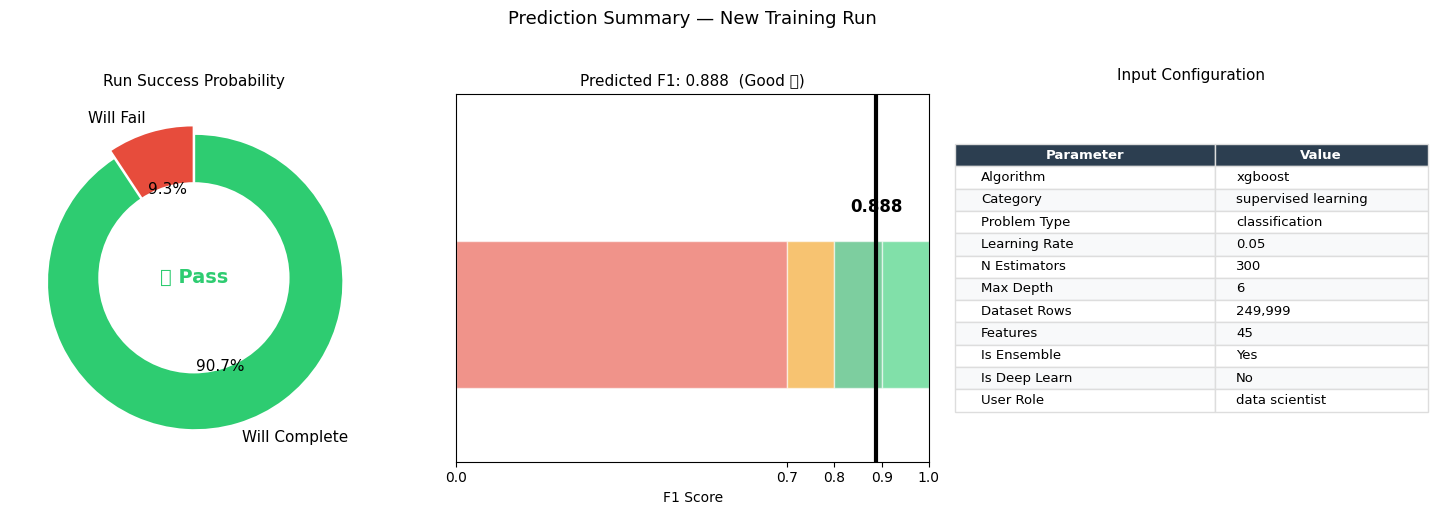

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Prediction Summary — New Training Run', fontsize=13, y=1.02)

# ── Plot 1: Success probability gauge (donut) ──
labels  = ['Will Fail', 'Will Complete']
sizes   = [prob_fail, prob_success]
colors  = ['#e74c3c', '#2ecc71']
explode = (0.03, 0.03)

axes[0].pie(sizes, labels=labels, colors=colors,
            explode=explode, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Run Success Probability', fontsize=11)

centre_circle = plt.Circle((0, 0), 0.65, fc='white')
axes[0].add_artist(centre_circle)

result_text = '✅ Pass' if success_pred == 1 else '❌ Fail'
axes[0].text(0, 0, result_text, ha='center', va='center',
             fontsize=14, fontweight='bold',
             color='#2ecc71' if success_pred == 1 else '#e74c3c')

# ── Plot 2: F1 score gauge bar ──
f1_thresholds = [0.0, 0.70, 0.80, 0.90, 1.0]
f1_colors     = ['#e74c3c', '#f39c12', '#27ae60', '#2ecc71']
f1_labels_bar = ['Poor\n<0.70', 'Fair\n0.70-0.80',
                 'Good\n0.80-0.90', 'Excellent\n≥0.90']

bar_widths = [0.70, 0.10, 0.10, 0.10]
bar_lefts  = [0.0, 0.70, 0.80, 0.90]

for bw, bl, bc, bl2 in zip(bar_widths, bar_lefts, f1_colors, f1_labels_bar):
    axes[1].barh(0, bw, left=bl, color=bc, height=0.4, alpha=0.6, edgecolor='white')

# Predicted F1 marker
axes[1].axvline(f1_pred, color='black', linewidth=3, zorder=5)
axes[1].text(f1_pred, 0.28, f'{f1_pred}', ha='center', fontsize=12,
             fontweight='bold', color='black')

axes[1].set_xlim(0, 1)
axes[1].set_ylim(-0.4, 0.6)
axes[1].set_yticks([])
axes[1].set_xlabel('F1 Score', fontsize=10)
axes[1].set_title(f'Predicted F1: {f1_pred}  ({f1_label})', fontsize=11)
axes[1].set_xticks([0, 0.70, 0.80, 0.90, 1.0])

# ── Plot 3: Key input parameters ──
axes[2].axis('off')

display_params = {
    'Algorithm'     : new_run.get('algorithm', 'N/A'),
    'Category'      : new_run.get('category', 'N/A'),
    'Problem Type'  : new_run.get('problem_type', 'N/A'),
    'Learning Rate' : new_run.get('learning_rate', 'N/A'),
    'N Estimators'  : new_run.get('n_estimators', 'N/A'),
    'Max Depth'     : new_run.get('max_depth', 'N/A'),
    'Dataset Rows'  : f"{int(np.expm1(new_run.get('log_total_train_rows', 0))):,}",
    'Features'      : new_run.get('max_features', 'N/A'),
    'Is Ensemble'   : 'Yes' if new_run.get('is_ensemble') == 1 else 'No',
    'Is Deep Learn' : 'Yes' if new_run.get('is_deep_learning') == 1 else 'No',
    'User Role'     : new_run.get('user_role', 'N/A'),
}

table_data  = [[k, str(v)] for k, v in display_params.items()]
col_labels  = ['Parameter', 'Value']

tbl = axes[2].table(
    cellText    = table_data,
    colLabels   = col_labels,
    cellLoc     = 'left',
    loc         = 'center',
    colWidths   = [0.55, 0.45]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.4)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#dddddd')
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f8f9fa')
    else:
        cell.set_facecolor('white')

axes[2].set_title('Input Configuration', fontsize=11, pad=10)

plt.tight_layout()
plt.show()


=== Batch Prediction Results ===
              Configuration Will Succeed  P(Complete) %  Predicted F1 F1 Grade
       XGBoost — Large Data          Yes           90.7        0.8880     Good
          BERT — Small Data          Yes           78.7        0.8993     Good
Random Forest — Medium Data          Yes           89.0        0.8910     Good


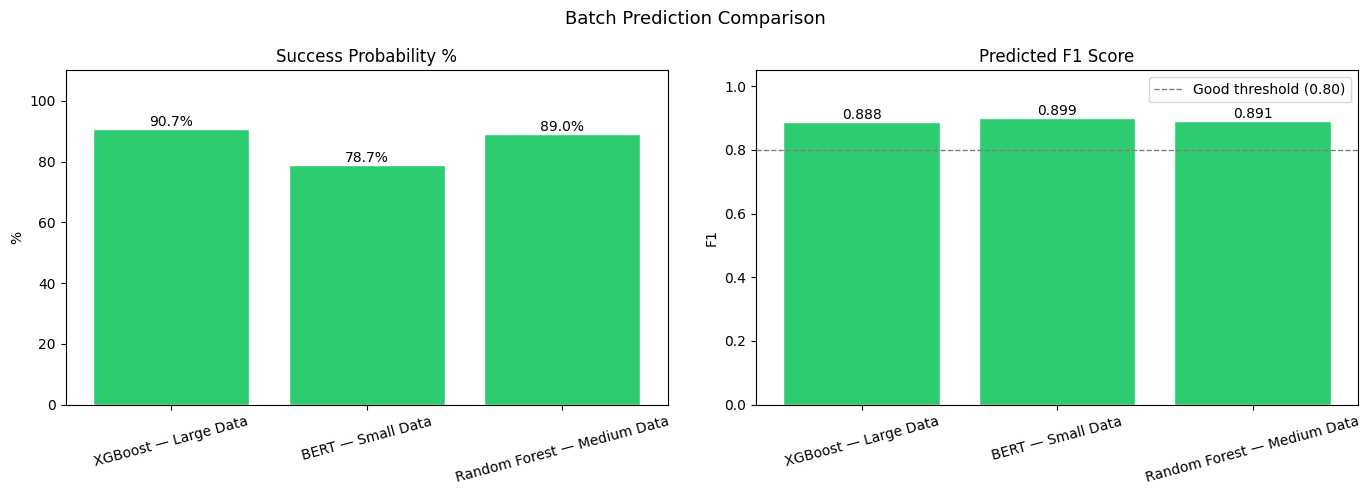

In [15]:
compare_runs = [
    {
        'label'                  : 'XGBoost — Large Data',
        'learning_rate'          : 0.05,
        'n_estimators'           : 300,
        'max_depth'              : 6,
        'batch_size'             : None,
        'epochs'                 : None,
        'num_leaves'             : None,
        'subsample'              : 0.8,
        'dropout'                : None,
        'weight_decay'           : None,
        'warmup_steps'           : None,
        'n_clusters'             : None,
        'gamma'                  : None,
        'clip_range'             : None,
        'reg_lambda'             : 1.0,
        'colsample_bytree'       : 0.7,
        'total_hyperparams'      : 6,
        'log_total_train_rows'   : np.log1p(250000),
        'max_features'           : 45,
        'avg_features'           : 40.0,
        'dataset_count'          : 2,
        'dataset_complexity_score': round(np.log1p(250000)*45, 4),
        'largest_dataset_rows'   : np.log1p(200000),
        'smallest_dataset_rows'  : np.log1p(50000),
        'hp_completeness'        : 5/7,
        'lr_x_epochs'            : 0.05 * 10,
        'data_richness'          : np.log1p(250000) * np.log1p(45),
        'feature_density'        : 45/3,
        'is_deep_learning'       : 0,
        'is_ensemble'            : 1,
        'is_business_hours'      : 1,
        'is_weekend'             : 0,
        'start_hour'             : 10,
        'start_month'            : 3,
        'duration_hours'         : None,
        'total_snapshots'        : None,
        'artifact_size_gb'       : None,
        'deployment_count'       : 0,
        'user_total_runs'        : 12,
        'user_success_rate_pct'  : 83.3,
        'is_public'              : 0,
        'category'               : 'supervised learning',
        'problem_type'           : 'classification',
        'algorithm'              : 'xgboost',
        'user_role'              : 'data scientist',
        'license_type'           : 'mit',
        'version_status'         : 'staging',
    },
    {
        'label'                  : 'BERT — Small Data',
        'learning_rate'          : 2e-5,
        'n_estimators'           : None,
        'max_depth'              : None,
        'batch_size'             : 32,
        'epochs'                 : 5,
        'num_leaves'             : None,
        'subsample'              : None,
        'dropout'                : 0.1,
        'weight_decay'           : 0.01,
        'warmup_steps'           : 500,
        'n_clusters'             : None,
        'gamma'                  : None,
        'clip_range'             : None,
        'reg_lambda'             : None,
        'colsample_bytree'       : None,
        'total_hyperparams'      : 5,
        'log_total_train_rows'   : np.log1p(15000),
        'max_features'           : 12,
        'avg_features'           : 12.0,
        'dataset_count'          : 1,
        'dataset_complexity_score': round(np.log1p(15000)*12, 4),
        'largest_dataset_rows'   : np.log1p(15000),
        'smallest_dataset_rows'  : np.log1p(15000),
        'hp_completeness'        : 4/7,
        'lr_x_epochs'            : 2e-5 * 5,
        'data_richness'          : np.log1p(15000) * np.log1p(12),
        'feature_density'        : 12/2,
        'is_deep_learning'       : 1,
        'is_ensemble'            : 0,
        'is_business_hours'      : 0,
        'is_weekend'             : 1,
        'start_hour'             : 22,
        'start_month'            : 11,
        'duration_hours'         : None,
        'total_snapshots'        : None,
        'artifact_size_gb'       : None,
        'deployment_count'       : 1,
        'user_total_runs'        : 5,
        'user_success_rate_pct'  : 60.0,
        'is_public'              : 1,
        'category'               : 'deep learning',
        'problem_type'           : 'nlp',
        'algorithm'              : 'bert',
        'user_role'              : 'ml engineer',
        'license_type'           : 'apache-2.0',
        'version_status'         : 'staging',
    },
    {
        'label'                  : 'Random Forest — Medium Data',
        'learning_rate'          : None,
        'n_estimators'           : 200,
        'max_depth'              : 12,
        'batch_size'             : None,
        'epochs'                 : None,
        'num_leaves'             : None,
        'subsample'              : None,
        'dropout'                : None,
        'weight_decay'           : None,
        'warmup_steps'           : None,
        'n_clusters'             : None,
        'gamma'                  : None,
        'clip_range'             : None,
        'reg_lambda'             : None,
        'colsample_bytree'       : None,
        'total_hyperparams'      : 3,
        'log_total_train_rows'   : np.log1p(80000),
        'max_features'           : 30,
        'avg_features'           : 28.0,
        'dataset_count'          : 1,
        'dataset_complexity_score': round(np.log1p(80000)*30, 4),
        'largest_dataset_rows'   : np.log1p(80000),
        'smallest_dataset_rows'  : np.log1p(80000),
        'hp_completeness'        : 2/7,
        'lr_x_epochs'            : 0,
        'data_richness'          : np.log1p(80000) * np.log1p(30),
        'feature_density'        : 30/2,
        'is_deep_learning'       : 0,
        'is_ensemble'            : 1,
        'is_business_hours'      : 1,
        'is_weekend'             : 0,
        'start_hour'             : 14,
        'start_month'            : 8,
        'duration_hours'         : None,
        'total_snapshots'        : None,
        'artifact_size_gb'       : None,
        'deployment_count'       : 0,
        'user_total_runs'        : 20,
        'user_success_rate_pct'  : 90.0,
        'is_public'              : 0,
        'category'               : 'supervised learning',
        'problem_type'           : 'regression',
        'algorithm'              : 'random forest',
        'user_role'              : 'data scientist',
        'license_type'           : 'mit',
        'version_status'         : 'production',
    },
]

# Run batch predictions
batch_results = []
for run in compare_runs:
    label = run.pop('label')
    row   = pd.DataFrame([run])

    # Ensure 'row' contains all columns defined in 'all_expected_cols'
    # and in the correct order for the pipelines.
    for col in all_expected_cols:
        if col not in row.columns:
            row[col] = np.nan
    row = row[all_expected_cols]

    s_pred  = clf_pipeline.predict(row)[0]
    s_proba = clf_pipeline.predict_proba(row)[0]
    f1      = float(np.clip(reg_pipeline.predict(row)[0], 0, 1))

    if   f1 >= 0.90: bucket = 'Excellent'
    elif f1 >= 0.80: bucket = 'Good'
    elif f1 >= 0.70: bucket = 'Fair'
    else:            bucket = 'Poor'

    batch_results.append({
        'Configuration'   : label,
        'Will Succeed'    : 'Yes' if s_pred == 1 else 'No',
        'P(Complete) %'   : round(s_proba[1] * 100, 1),
        'Predicted F1'    : round(f1, 4),
        'F1 Grade'        : bucket,
    })

batch_df = pd.DataFrame(batch_results)
print("=== Batch Prediction Results ===")
print(batch_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Batch Prediction Comparison', fontsize=13)

bar_colors_s = ['#2ecc71' if v == 'Yes' else '#e74c3c'
                for v in batch_df['Will Succeed']]
bar_colors_f = ['#2ecc71' if v >= 0.80 else '#f39c12' if v >= 0.70 else '#e74c3c'
                for v in batch_df['Predicted F1']]

axes[0].bar(batch_df['Configuration'], batch_df['P(Complete) %'],
            color=bar_colors_s, edgecolor='white')
axes[0].set_title('Success Probability %')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[0].patches, batch_df['P(Complete) %']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, f'{val}%',
                 ha='center', fontsize=10)

axes[1].bar(batch_df['Configuration'], batch_df['Predicted F1'],
            color=bar_colors_f, edgecolor='white')
axes[1].set_title('Predicted F1 Score')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(0.80, color='gray', linestyle='--',
                linewidth=1, label='Good threshold (0.80)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
for bar, val in zip(axes[1].patches, batch_df['Predicted F1']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01, f'{val:.3f}',
                 ha='center', fontsize=10)

plt.tight_layout()
plt.show()